In [1]:
!git clone https://github.com/parth1620/Facial-Expression-Dataset.git
!pip install -U git+https://github.com/albumentations-team/albumentations
!pip install timm
!pip install --upgrade opencv-contrib-python

Cloning into 'Facial-Expression-Dataset'...
remote: Enumerating objects: 34052, done.
remote: Total 34052 (delta 0), reused 0 (delta 0), pack-reused 34052 (from 1)
Receiving objects: 100% (34052/34052), 52.31 MiB | 14.33 MiB/s, done.
Resolving deltas: 100% (4/4), done.
Updating files: 100% (35887/35887), done.
  Cloning https://github.com/albumentations-team/albumentations to /tmp/pip-req-build-0rc87u56
  Running command git clone --filter=blob:none --quiet https://github.com/albumentations-team/albumentations /tmp/pip-req-build-0rc87u56
  Resolved https://github.com/albumentations-team/albumentations to commit 8425673d341d8a8de5c9d5ac675c625bee80dd95
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Attempting uninstall: albucore
    Found existing installation: albucore 0.0.23
    Uninstalling albucore-0.0.23:
      Successfully uninstalled albucore-0.0.23
ERROR: pip's dependency resolver does not 

In [2]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt


In [3]:
TRAIN_IMG_FOLDER_PATH = '/content/Facial-Expression-Dataset/train/'
VALID_IMG_FOLDER_PATH = '/content/Facial-Expression-Dataset/validation/'

LR = 0.001
BATCH_SIZE = 32
EPOCHS = 15

DEVICE = 'cuda'
MODEL_NAME = 'efficientnet_b0'

In [4]:
from torchvision.datasets import ImageFolder
from torchvision import transforms as T

In [6]:
train_augs = T.Compose([
    T.RandomHorizontalFlip(p = 0.5),
    T.RandomRotation(degrees = (-20, +20)),
    T.ToTensor() #PIL - numpy -> torch tensor & (h,w,c) -> (c,h,w)
])

valid_augs = T.Compose([
    T.ToTensor()
])

In [8]:
trainset = ImageFolder(TRAIN_IMG_FOLDER_PATH, transform=train_augs)
validset = ImageFolder(VALID_IMG_FOLDER_PATH, transform= valid_augs)


In [9]:
print(f'Length of Trainset:{len(trainset)}')
print(f'Length of validset:{len(validset)}')

Length of Trainset:28821
Length of validset:7066


In [12]:
print(trainset.class_to_idx)

{'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}


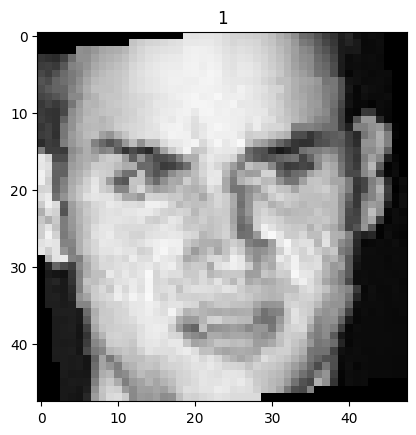

In [15]:
image, label = trainset[4100]

plt.imshow(image.permute(1,2,0))
plt.title(label);

In [16]:
from torch.utils.data import DataLoader

In [17]:
trainloader = DataLoader(trainset, batch_size = BATCH_SIZE, shuffle=True)
validloader = DataLoader(validset, batch_size = BATCH_SIZE)


In [18]:
print(f'Length of Batches in trainloader :{len(trainloader)}')
print(f'Length of Batches in validloader :{len(validloader)}')


Length of Batches in trainloader :901
Length of Batches in validloader :221


In [19]:
for images, labels in trainloader:
  break;

print(f'One image batch shape : {images.shape}')
print(f'one label batch shape :{labels.shape}')

One image batch shape : torch.Size([32, 3, 48, 48])
one label batch shape :torch.Size([32])


In [21]:
import timm
from torch import nn

In [24]:
class FaceModel(nn.Module):

   def __init__(self):
    super(FaceModel, self).__init__()

    self.eff_net = timm.create_model('efficientnet_b0', pretrained= True, num_classes= 7)

   def forward(self, images, labels = None):
    logits = self.eff_net(images)

    if labels !=None:
      loss = nn.CrossEntropyLoss()(logits, labels)
      return logits, loss

    return logits

In [25]:
model = FaceModel()
model.to(DEVICE)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

FaceModel(
  (eff_net): EfficientNet(
    (conv_stem): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (bn1): BatchNormAct2d(
      32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
      (drop): Identity()
      (act): SiLU(inplace=True)
    )
    (blocks): Sequential(
      (0): Sequential(
        (0): DepthwiseSeparableConv(
          (conv_dw): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (bn1): BatchNormAct2d(
            32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
            (drop): Identity()
            (act): SiLU(inplace=True)
          )
          (aa): Identity()
          (se): SqueezeExcite(
            (conv_reduce): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (act1): SiLU(inplace=True)
            (conv_expand): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (gate): Sigmoid()
          )
          (conv_pw): Conv

In [20]:
from tqdm import tqdm

In [26]:
def multiclass_accuracy(y_pred, y_true):
  top_p, top_class = y_pred.topk(1, dim =1)
  equals = top_class == y_true.view(*top_class.shape)
  return torch.mean(equals.type(torch.FloatTensor))

In [27]:
def train_fn(model, dataloader, optimizer, current_epo):
  model.train()
  total_loss = 0.0
  total_acc = 0.0
  tk = tqdm(dataloader, desc = "EPOC" + "[TRAIN]" + str(current_epo + 1) + "/" + str(EPOCHS))

  for t, data in enumerate(tk):
    images, labels = data
    images, labels = images.to(DEVICE), labels.to(DEVICE)

    optimizer.zero_grad()
    logits, loss = model(images, labels)
    loss.backward()
    optimizer.step()

    total_loss += loss.item()
    total_acc += multiclass_accuracy(logits, labels)
    tk.set_postfix({'loss' : '%6f' %float(total_loss/(t+1)), 'acc' : '%6f' %float(total_acc/(t+1)) })

  return total_loss / len(dataloader), total_acc / len(dataloader)


In [29]:
def eval_fn(model, dataloader, current_epo):
  model.eval()
  total_loss = 0.0
  total_acc = 0.0
  tk = tqdm(dataloader, desc = "EPOC" + "[VALID]" + str(current_epo + 1) + "/" + str(EPOCHS))

  for t, data in enumerate(tk):
    images, labels = data
    images, labels = images.to(DEVICE), labels.to(DEVICE)

    logits, loss = model(images, labels)

    total_loss += loss.item()
    total_acc += multiclass_accuracy(logits, labels)
    tk.set_postfix({'loss' : '%6f' %float(total_loss/(t+1)), 'acc' : '%6f' %float(total_acc/(t+1)) })

  return total_loss / len(dataloader), total_acc / len(dataloader)


In [30]:
optimizer = torch.optim.Adam(model.parameters(), lr = LR)

In [33]:
best_valid_loss = np.inf

for i in range(EPOCHS):
  train_loss, train_acc = train_fn(model, trainloader, optimizer, i)
  valid_loss, valid_acc = eval_fn(model, validloader, i)

  if valid_loss < best_valid_loss:
    torch.save(model.state_dict(), 'best-weights.pt')
    print("SAVED-BEST-WEIGHTS")
    best_valid_loss = valid_loss


EPOC[VALID]1/15: 100%|██████████| 221/221 [00:06<00:00, 36.27it/s, loss=1.027919, acc=0.634800]


SAVED-BEST-WEIGHTS


EPOC[VALID]2/15: 100%|██████████| 221/221 [00:06<00:00, 33.38it/s, loss=1.002599, acc=0.646167]


SAVED-BEST-WEIGHTS


EPOC[VALID]3/15: 100%|██████████| 221/221 [00:06<00:00, 36.56it/s, loss=0.995921, acc=0.648386]


SAVED-BEST-WEIGHTS


EPOC[VALID]15/15: 100%|██████████| 221/221 [00:06<00:00, 33.90it/s, loss=1.196692, acc=0.647081]


In [48]:
def view_classify(img, ps):

    classes = ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

    ps = ps.data.cpu().numpy().squeeze()
    img = img.numpy().transpose(1,2,0)

    fig, (ax1, ax2) = plt.subplots(figsize=(5,9), ncols=2)
    ax1.imshow(img)
    ax1.axis('off')
    ax2.barh(classes, ps)
    ax2.set_aspect(0.1)
    ax2.set_yticks(classes)
    ax2.set_yticklabels(classes)
    ax2.set_title('Class Probability')
    ax2.set_xlim(0, 1.1)

    plt.tight_layout()

    return fig


In [49]:
# def view_classify(img, ps):
#     import matplotlib.pyplot as plt
#     import numpy as np

#     classes = ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

#     ps = ps.data.cpu().numpy().squeeze()
#     img = img.cpu().numpy().squeeze()  # Only squeeze here — don't transpose for grayscale

#     fig, (ax1, ax2) = plt.subplots(figsize=(5, 9), ncols=2)
#     ax1.imshow(img, cmap='gray')  # Specify grayscale colormap
#     ax1.axis('off')

#     ax2.barh(classes, ps)
#     ax2.set_aspect(0.1)
#     ax2.set_yticks(range(len(classes)))
#     ax2.set_yticklabels(classes)
#     ax2.set_title('Class Probability')
#     ax2.set_xlim(0, 1.1)

#     plt.tight_layout()
#     return fig


<ipython-input-38-d0c55bbdc49f>:9: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax1.imshow(img)


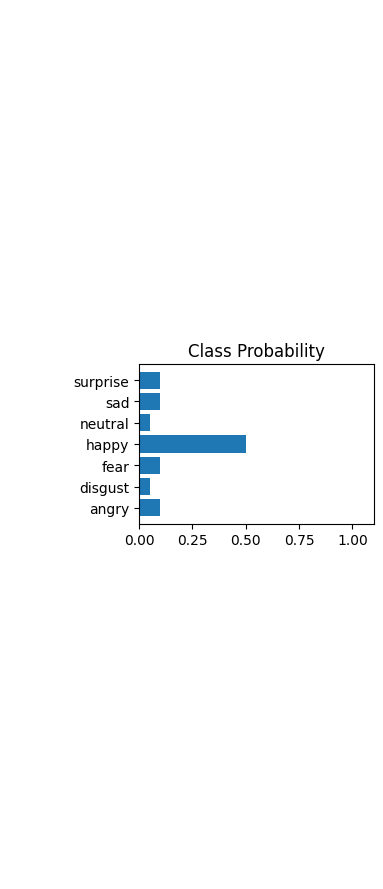

In [47]:
# import torch
# import matplotlib.pyplot as plt

# # Example random image and prediction for demo purposes
# img = torch.rand(1, 2, 0)  # Replace with your actual image tensor (3xHxW)
# ps = torch.tensor([[0.1, 0.05, 0.1, 0.5, 0.05, 0.1, 0.1]])  # Replace with actual output probabilities

# # Call the function
# view_classify(img, ps)

# # Show the plot
# plt.show()
